# SAMPIClyser Analysis

Start by loading the required libraries.
This repositories implements "database" libraries to get all run information

In [1]:
from pathlib import Path

In [2]:
from PPS_TB_202505_RunDB import runs_to_configs, run_config_info
from PPS_TB_202505_RunDB import run_info as run_info_dict

Define which run you want to process and load the run information

In [3]:
run_to_process = "Run008"

parquet_file = Path(f"./{run_to_process}.parquet")
root_file = Path(f"./{run_to_process}.root")

run_info = run_info_dict[run_to_process]
config_key = runs_to_configs[run_to_process]
config_info = run_config_info[config_key]

## Hits Per Channel

In [4]:
from sampiclyser.sampic_tools import get_channel_hits
from sampiclyser.sampic_tools import plot_channel_hits

In [5]:
hit_summary = get_channel_hits(root_file)
hit_summary

,Channel,Hits
0,0,9519
1,1,23793
2,2,35144
3,3,43682
4,4,37336
5,5,67707
6,6,128624
7,7,177739
8,8,179665
9,9,102549


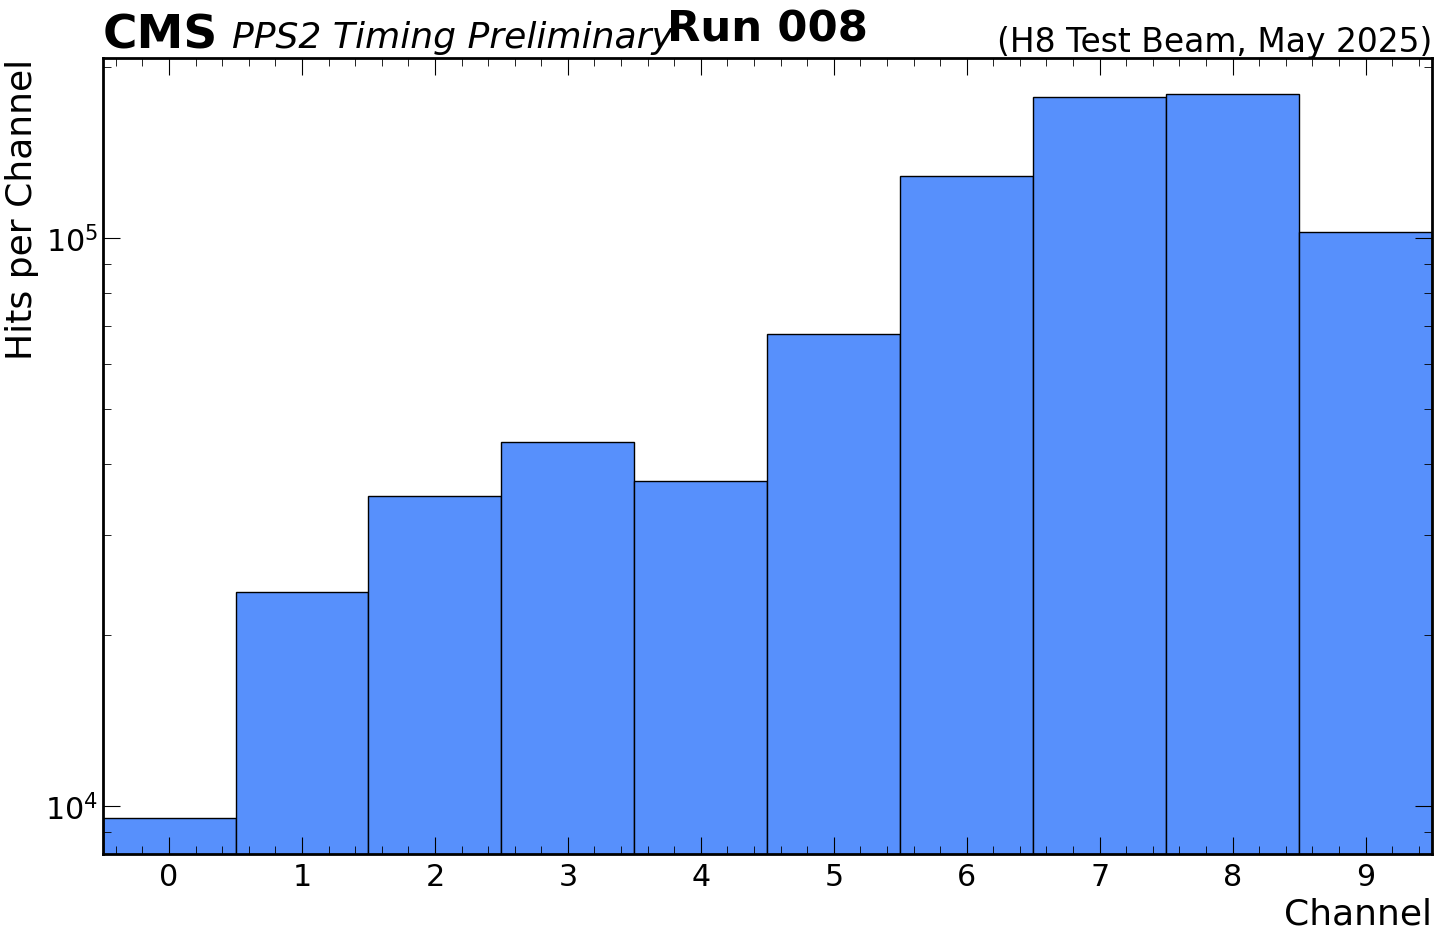

In [6]:
title = run_info.name
fig = plot_channel_hits(hit_summary, 0, 9, label="PPS2 Timing Preliminary", rlabel="(H8 Test Beam, May 2025)", log_y=True, figsize = (15, 10), title=title)

## Draw Hitmap

In [7]:
from sampiclyser.sensor_hitmaps import plot_hitmap

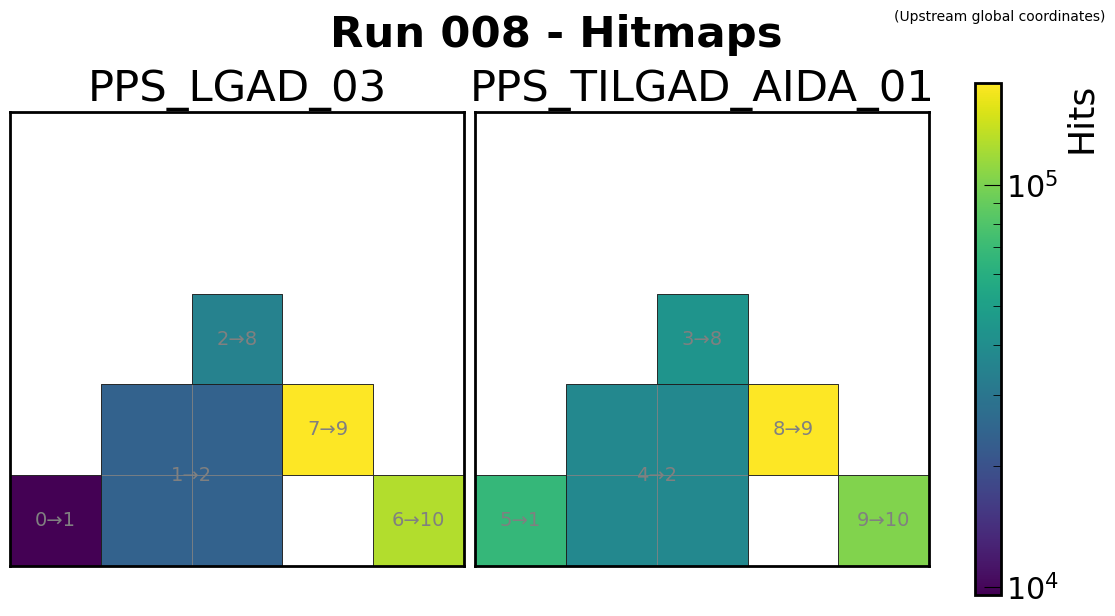

In [8]:
plot_title = run_info.name + " - Hitmaps"

board_spec = [config_info.board_spec[board] for board in config_info.board_order]

fig = plot_hitmap(
    hit_summary,
    specs=board_spec,
    layout=(1, 2),
    figsize=(11,6),
    log_z = True,
    title = plot_title,
    do_sampic_ch = True,
    do_board_ch= True,
    coordinates="global",
)

fig

## Overall Hit Rate

In [9]:
from sampiclyser.sampic_tools import plot_hit_rate
import datetime

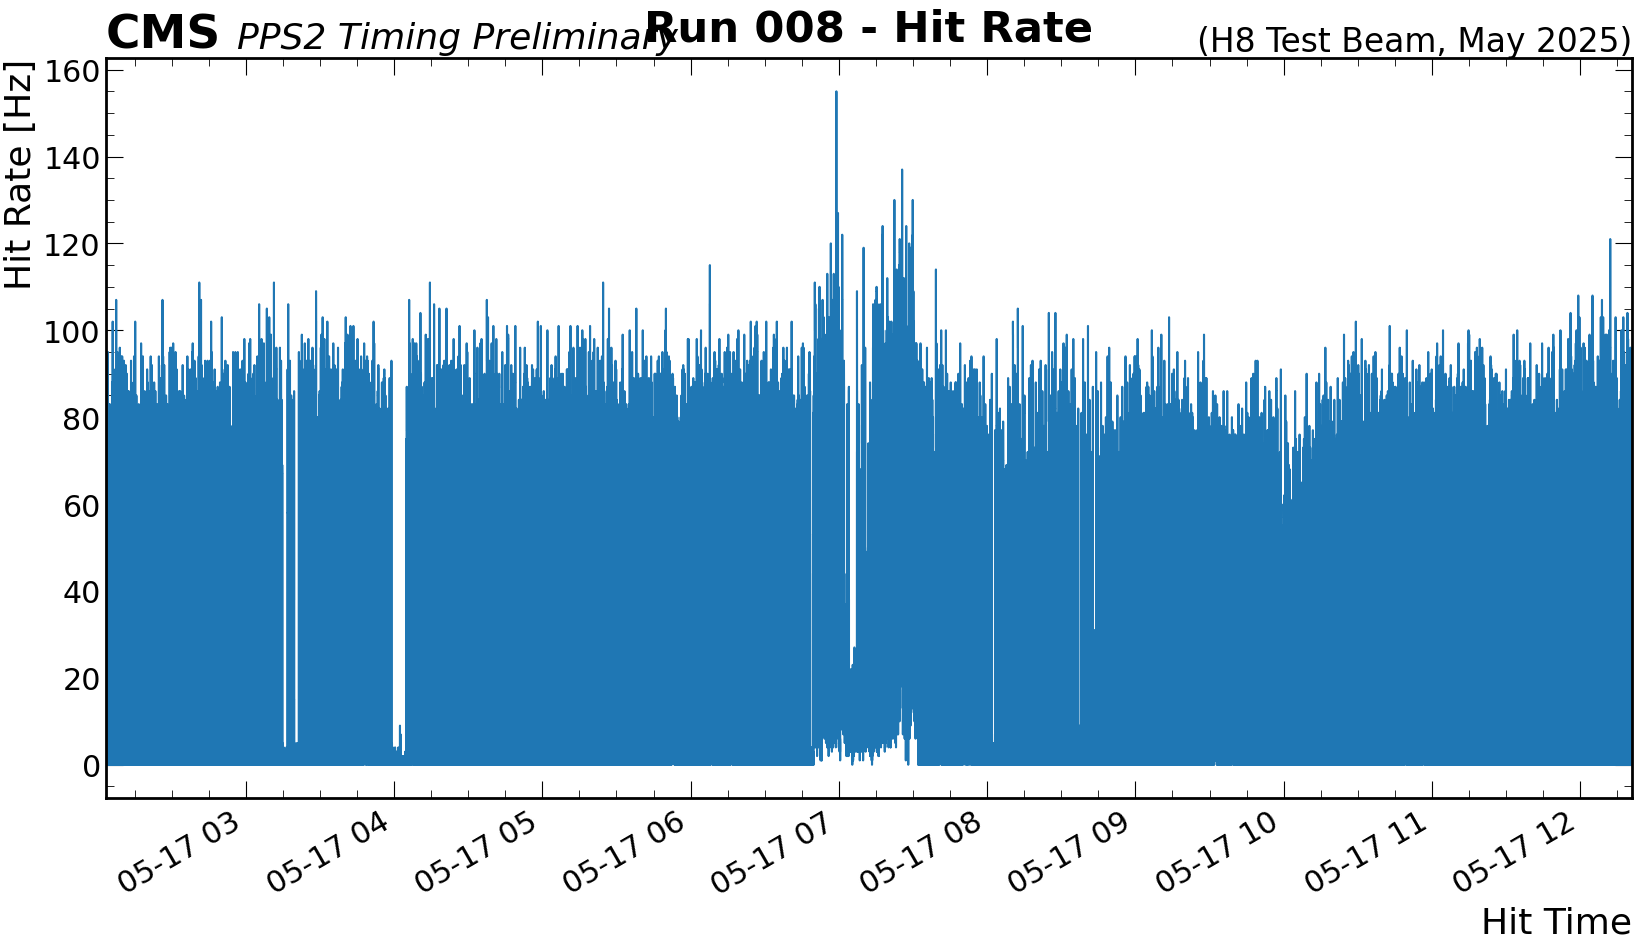

In [10]:
plot_title = run_info.name + " - Hit Rate"

fig = plot_hit_rate(
    root_file,
    plot_hits=False,
    bin_size=1,
    #start_time=datetime.datetime(2025, 5, 15, 23, 27),
    #end_time=datetime.datetime(2025, 5, 15, 23, 57),
    label="PPS2 Timing Preliminary",
    rlabel="(H8 Test Beam, May 2025)",
    #log_y=True,
    figsize = (17, 10),
    title=plot_title,
    )

fig

## Channel Hit Rate

In [11]:
from sampiclyser import plot_channel_hit_rate

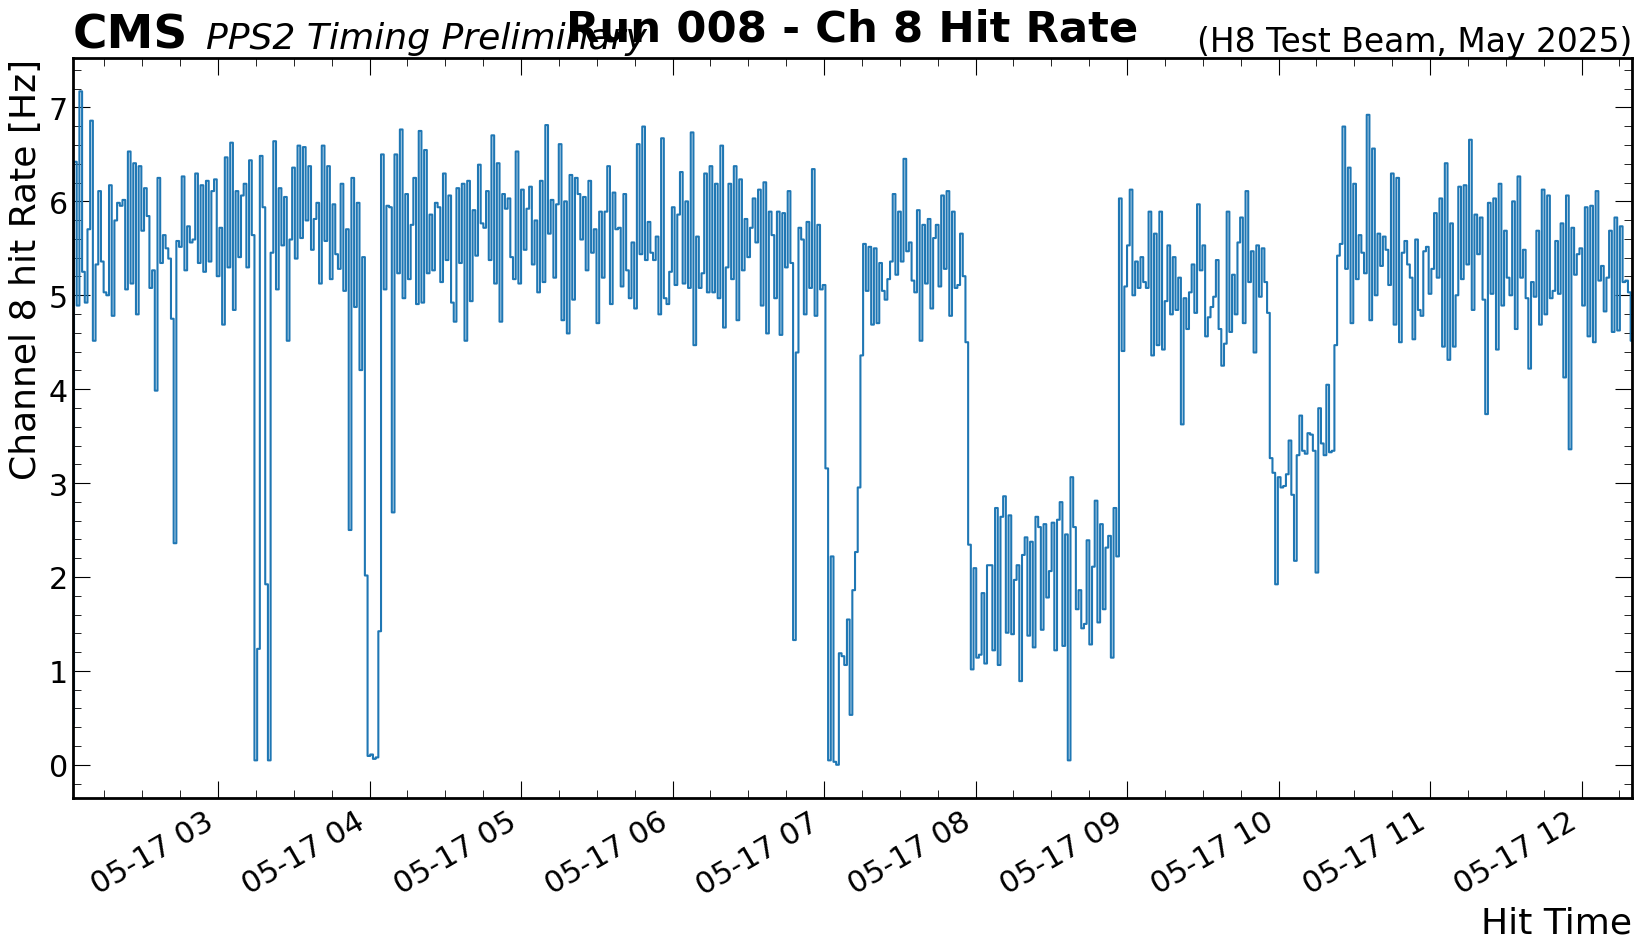

In [12]:
channel = 8
plot_title = run_info.name + f" - Ch {channel} Hit Rate"

plot_channel_hit_rate(
    root_file,
    channel = channel,
    bin_size=64,
    #start_time=datetime.datetime(2025, 5, 15, 23, 27),
    #end_time=datetime.datetime(2025, 5, 15, 23, 57),
    #start_time=datetime.datetime(2025, 5, 17, 1, 10),
    #end_time=datetime.datetime(2025, 5, 17, 1, 30),
    label="PPS2 Timing Preliminary",
    rlabel="(H8 Test Beam, May 2025)",
    #log_y=True,
    figsize = (17, 10),
    title=plot_title,
)

## Plot Some waveforms

In [13]:
from sampiclyser.sampic_tools import plot_channel_waveforms

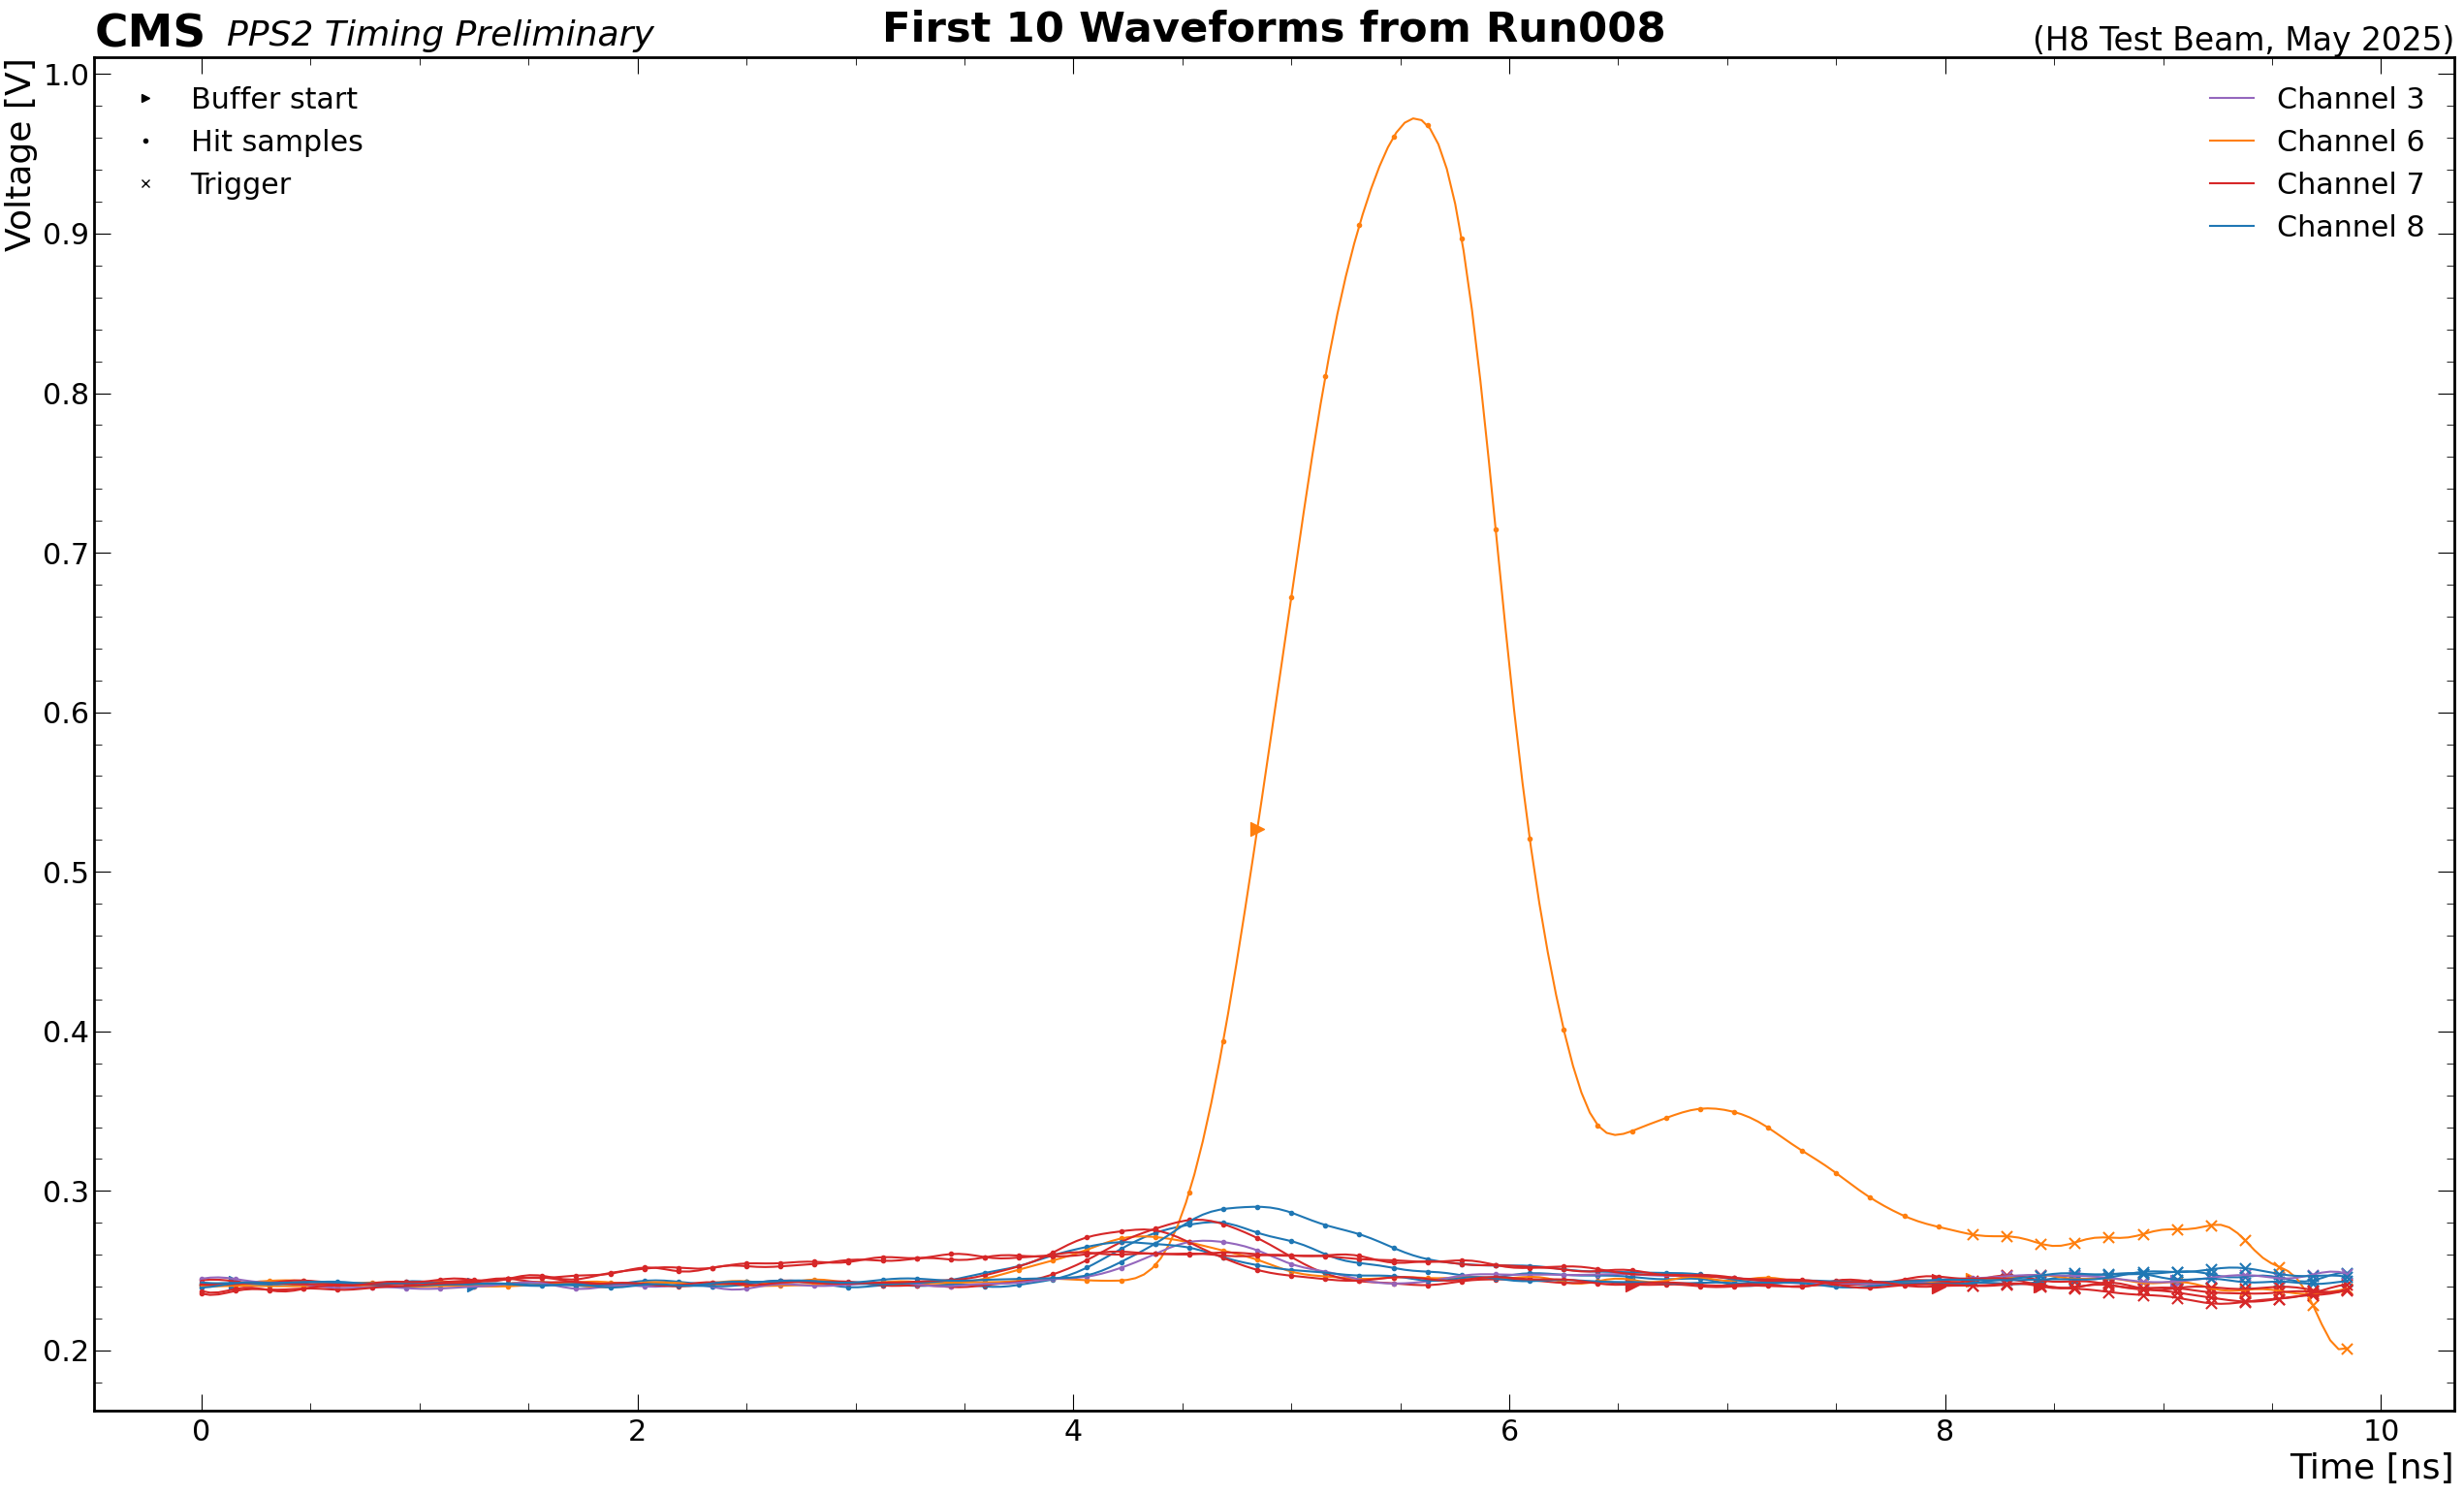

In [14]:
plot_channel_waveforms(
    #Path("test.parquet"),
    root_file,
    interpolation_method='sinc',
    cmap='tab10',
    figsize=(26,16),
    first_hit=0,
    num_hits=10,
    #channel_filter=[9],
    #channel_filter=[4, 5, 7],
    label="PPS2 Timing Preliminary",
    rlabel="(H8 Test Beam, May 2025)",
    log_y=False,
    #title=plot_title,
    is_data=True,
    file_name_id=run_to_process,
    )